Initial Data Preview:


,Trial_ID,Country,Disease,Start_Date,Status,Sponsor,Enrollment
0,T001,india,Cancer,2020-01-01,Completed,PharmaCorp,100.0
1,T002,India,Diabetes,01/02/2021,Active,HealthGen,150.0
2,T003,USA,Cancer,March 3 2022,Completed,PharmaCorp,200.0
3,T004,usa,Cardiovascular,2022/04/01,Terminated,BioLife,NaN
4,T005,NaN,Cancer,2021-05-10,Active,MedX,120.0
5,T006,UK,Diabetes,NaN,Completed,HealthGen,130.0
6,T007,India,Cancer,2020-01-01,Completed,PharmaCorp,100.0
7,T008,Canada,Neurology,2023-02-15,Active,BioLife,180.0



Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Trial_ID    8 non-null      object 
 1   Country     7 non-null      object 
 2   Disease     8 non-null      object 
 3   Start_Date  7 non-null      object 
 4   Status      8 non-null      object 
 5   Sponsor     8 non-null      object 
 6   Enrollment  7 non-null      float64
dtypes: float64(1), object(6)
memory usage: 580.0+ bytes
None

Missing Values:
Trial_ID      0
Country       1
Disease       0
Start_Date    1
Status        0
Sponsor       0
Enrollment    1
dtype: int64


nan not found in ISO3



Cleaned Data Preview:


,Trial_ID,Disease,Start_Date,Status,Sponsor,Enrollment,Country_Standard,Year
0,T001,Cancer,2020-01-01,Completed,PharmaCorp,100.0,India,2020
1,T002,Diabetes,2021-02-01,Active,HealthGen,150.0,India,2021
2,T003,Cancer,2022-03-03,Completed,PharmaCorp,200.0,United States,2022
3,T004,Cardiovascular,2022-04-01,Terminated,BioLife,0.0,United States,2022
4,T005,Cancer,2021-05-10,Active,MedX,120.0,Unknown,2021
5,T006,Diabetes,NaT,Completed,HealthGen,130.0,United Kingdom,<NA>
6,T008,Neurology,2023-02-15,Active,BioLife,180.0,Canada,2023



Top Countries:
Country_Standard
India             2
United States     2
Unknown           1
United Kingdom    1
Canada            1
Name: count, dtype: int64

Top Diseases:
Disease
Cancer            3
Diabetes          2
Cardiovascular    1
Neurology         1
Name: count, dtype: int64

Trend Over Time:
Year
2020    1
2021    2
2022    2
2023    1
Name: count, dtype: Int64

Trend Over Time:
Year
2020    1
2021    2
2022    2
2023    1
<NA>    1
Name: count, dtype: Int64


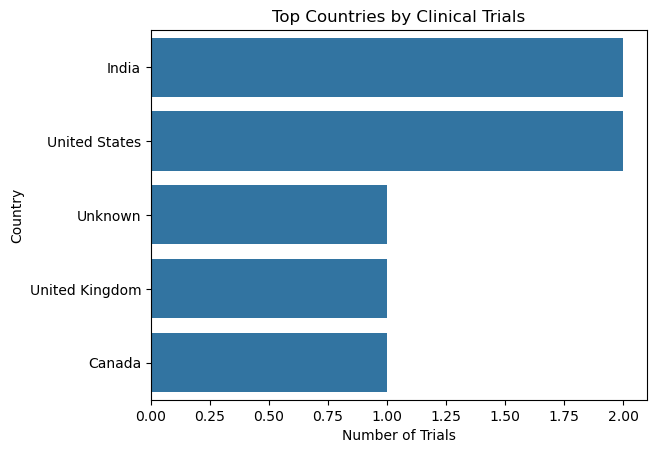

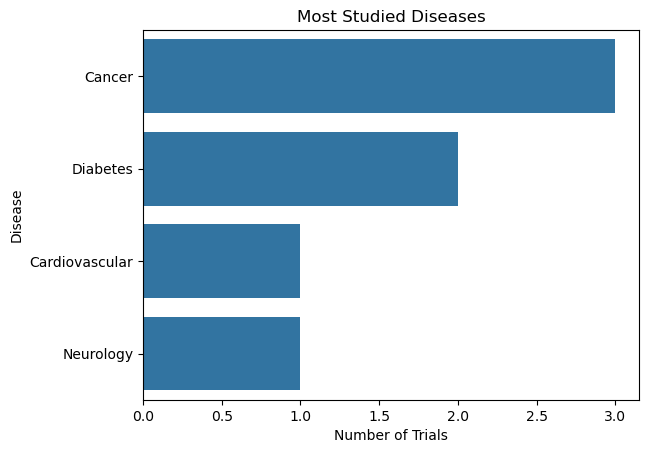

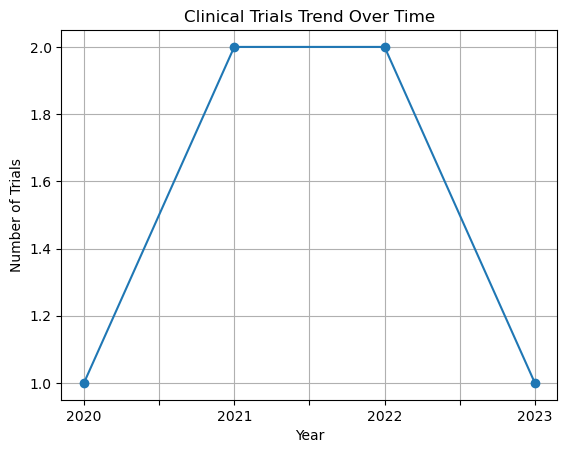

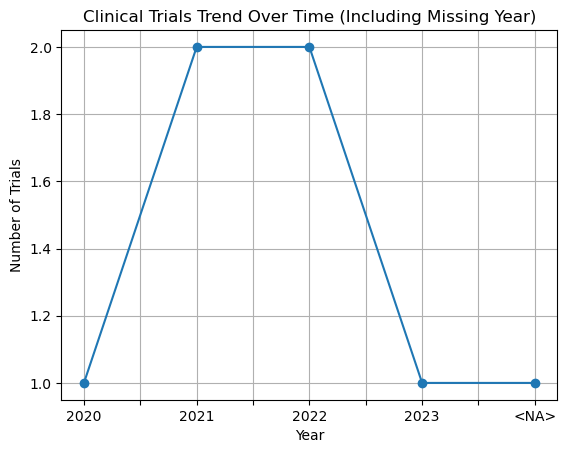

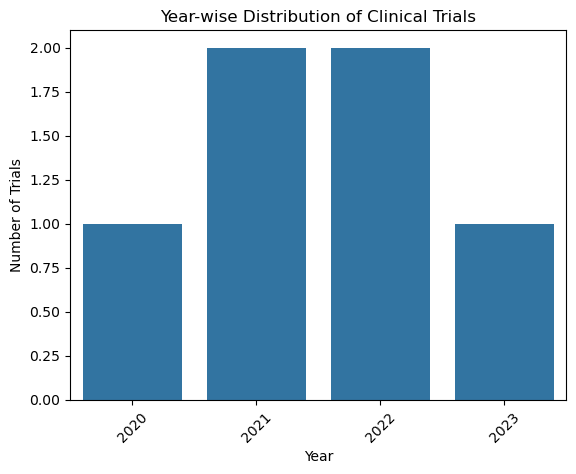

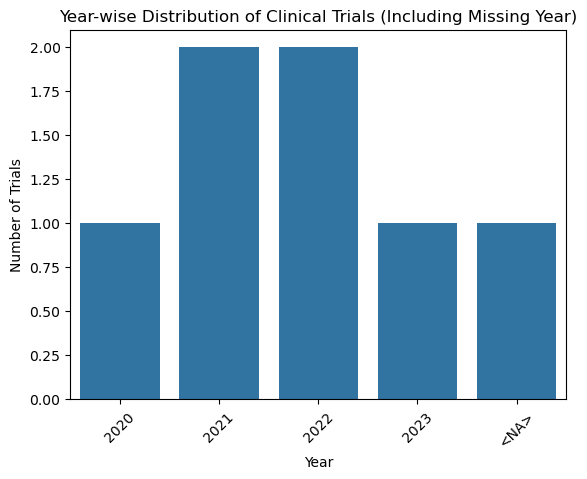

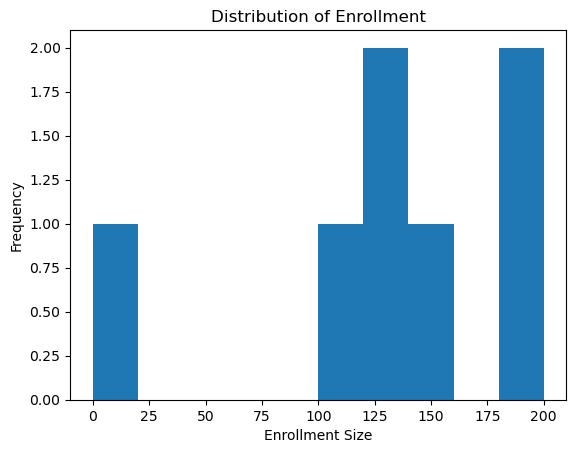


Files saved successfully!


In [ ]:
# ================================
# 📊 Healthcare Data Analysis Project
# ================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import country_converter as coco

# -------------------------------
# 1. Load Data
# -------------------------------
df = pd.read_csv('../data/raw/clinical_trials.csv')

print("Initial Data Preview:")
display(df.head(10))

print("\nData Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())


# -------------------------------
# 2. Data Cleaning
# -------------------------------

df_clean = df.copy()

# Removed extra spaces from Country names
df_clean['Country'] = df_clean['Country'].str.strip()

# Initialize country converter
cc = coco.CountryConverter()

# Standardize country names
df_clean['Country_Standard'] = cc.pandas_convert(
    series=df_clean['Country'],
    to='name_short'
)

# Replace 'not found' with NaN and fill
df_clean['Country_Standard'] = (
    df_clean['Country_Standard']
    .replace('not found', np.nan)
    .fillna('Unknown')
)

# Handle missing enrollment
df_clean['Enrollment'] = df_clean['Enrollment'].fillna(0.0)

# Clean and convert Start_Date
df_clean['Start_Date'] = (
    df_clean['Start_Date']
    .astype(str)
    .str.strip()
)

df_clean['Start_Date'] = pd.to_datetime(
    df_clean['Start_Date'],
    dayfirst=True,
    errors='coerce',
    format='mixed'
)

# Extract Year
df_clean['Year'] = df_clean['Start_Date'].dt.year.astype('Int64')

# Drop original Country column
df_clean = df_clean.drop(columns=['Country'])

# Remove duplicate records (excluding Trial_ID)
df_clean = df_clean.drop_duplicates(
    subset=df_clean.columns.difference(['Trial_ID'])
)

# Reset index
df_clean = df_clean.reset_index(drop=True)

print("\nCleaned Data Preview:")
display(df_clean.head(10))


# -------------------------------
# 3. Data Analysis
# -------------------------------

# Top Countries
top_countries = df_clean['Country_Standard'].value_counts().head(10)
print("\nTop Countries:")
print(top_countries)

# Most Studied Diseases
top_disease = df_clean['Disease'].value_counts().head(10)
print("\nTop Diseases:")
print(top_disease)

# Note:
# Missing years are excluded from trend analysis to maintain accuracy

# Trend Over Time - missing year excluded
trend = df_clean['Year'].value_counts().sort_index() # does not count <NA> by default
print("\nTrend Over Time:")
print(trend)

# Note:
# Missing dates are included as a separate category (<NA>) to ensure transparency in analysis

# Trend Over Time - missing year included as <NA>
trend1 = df_clean['Year'].value_counts(dropna=False).sort_index()
print("\nTrend Over Time:")
print(trend1)

# -------------------------------
# 4. Visualization
# -------------------------------

# -------------------------------
# 4.1 Top Countries
# -------------------------------

plt.figure()
sns.barplot(x=top_countries.values, y=top_countries.index)

plt.title("Top Countries by Clinical Trials")
plt.xlabel("Number of Trials")
plt.ylabel("Country")

plt.show()

# -------------------------------
# 4.2 Most Studied Diseases
# -------------------------------

plt.figure()
sns.barplot(x=top_disease.values, y=top_disease.index)

plt.title("Most Studied Diseases")
plt.xlabel("Number of Trials")
plt.ylabel("Disease")

plt.show()

# -------------------------------
# 4.3 Trend Over Time - Line Plot
# -------------------------------

# -------------------------------
# (a) Excluding Missing Year
# -------------------------------
trend.index = trend.index.astype(str)

plt.figure()
trend.plot(marker='o')

plt.title("Clinical Trials Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Trials")

plt.grid()
plt.show()

# -------------------------------
# (b) Including Missing Year
# -------------------------------

trend1.index = trend1.index.astype(str)

plt.figure()
trend1.plot(marker='o')

plt.title("Clinical Trials Trend Over Time (Including Missing Year)")
plt.xlabel("Year")
plt.ylabel("Number of Trials")

plt.grid()
plt.show()

# -------------------------------
# 4.4 Trend Over Time - Bar Plot
# -------------------------------

# -------------------------------
# (a) Excluding Missing Year
# -------------------------------

plt.figure()
sns.barplot(x=trend.index, y=trend.values)

plt.title("Year-wise Distribution of Clinical Trials")
plt.xlabel("Year")
plt.ylabel("Number of Trials")

plt.xticks(rotation=45)
plt.show()

# -------------------------------
# (b) Including Missing Year
# -------------------------------

trend1.index = trend1.index.astype(str)

plt.figure()
sns.barplot(x=trend1.index, y=trend1.values)

plt.title("Year-wise Distribution of Clinical Trials (Including Missing Year)")
plt.xlabel("Year")
plt.ylabel("Number of Trials")

plt.xticks(rotation=45)
plt.show()

# -------------------------------
# 4.5 Enrollment Distribution (Bonus Insight)
# -------------------------------

plt.figure()
plt.hist(df_clean['Enrollment'], bins=10)

plt.title("Distribution of Enrollment")
plt.xlabel("Enrollment Size")
plt.ylabel("Frequency")

plt.show()

# -------------------------------
# 5. Save Clean Data
# -------------------------------

df_clean.to_csv('cleaned_clinical_trials.csv', index=False)
#df_clean.to_excel('cleaned_clinical_trials.xlsx', index=False)

print("\nFiles saved successfully!")